# 서울시 100m 격자 총인구 추정

## 목적
- 500m 총인구와 100m 원본 인구의 차이를 100m 격자에 재배분
- 기존 인구, 주택 수, 주거면적을 결합한 네 가지 배분지수 비교
- 최종 추정인구를 정수화하면서 500m별 총인구 보존

## 최종 배분식

$$
\hat{P}_i = P_i + (P^{500}_g - \sum_{i \in g} P_i) \times \tilde{I}_i
$$

- 최종 지수: 기존 인구 30% + 주택 수 50% + 주거면적 20%
- 지수 합이 0인 500m 격자는 내부 100m 격자에 균등 배분

In [1]:
import pathlib

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point

plt.rcParams["font.family"] = "Noto Sans KR"
plt.rcParams["axes.unicode_minus"] = False

## 경로 설정

In [2]:
BASE_PATH = pathlib.Path.cwd().resolve()

if not (BASE_PATH / "data").exists():
    for parent in BASE_PATH.parents:
        if (parent / "data").exists():
            BASE_PATH = parent
            break

RAW_PATH = BASE_PATH / "data" / "raw"
PROCESSED_PATH = BASE_PATH / "data" / "processed"
SPATIAL_PATH = PROCESSED_PATH / "spatial"
OUTPUT_PATH = PROCESSED_PATH / "estimated_population"

POPULATION_GRID_PATH = RAW_PATH / "population" / "grid"
SPATIAL_GRID_PATH = RAW_PATH / "spatial" / "grid"
DEMOGRAPHICS_PATH = RAW_PATH / "population" / "demographics" / "source"

BASE_GRID_FILE = SPATIAL_PATH / "서울시_격자_100m_행정동_기본테이블.gpkg"
OUTPUT_500_FILE = OUTPUT_PATH / "서울시_격자_500m_총인구.gpkg"
OUTPUT_100_FILE = OUTPUT_PATH / "서울시_100m_추정인구.gpkg"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

## 공통 함수

In [3]:
def read_district_shapefiles(folder, value_name, code_name):
    shp_files = sorted(folder.glob("*/vl_blk.shp"))
    assert shp_files, f"Shapefile이 없습니다: {folder}"

    frames = []
    for path in shp_files:
        frame = gpd.read_file(path, encoding="utf-8")
        frame["시군구"] = path.parent.name
        frames.append(frame)

    result = gpd.GeoDataFrame(
        pd.concat(frames, ignore_index=True),
        geometry="geometry",
        crs=frames[0].crs,
    )
    return result.rename(columns={"gid": code_name, "val": value_name})


def summarize_quality(data, key, value):
    return pd.Series({
        "행 수": len(data),
        "코드 중복": int(data[key].duplicated().sum()),
        "값 결측": int(data[value].isna().sum()),
        "값 합계": float(data[value].sum()),
        "유효하지 않은 geometry": int((~data.geometry.is_valid).sum()),
    }, name="확인값")

## 100m 기본격자와 원본 인구

In [4]:
assert BASE_GRID_FILE.exists(), "1번 노트북의 기본격자 결과가 없습니다."
grid100 = gpd.read_file(BASE_GRID_FILE)

pop100 = read_district_shapefiles(
    POPULATION_GRID_PATH / "100m_total_population",
    value_name="총인구수",
    code_name="GRID_CD",
)
pop100["총인구수"] = pop100["총인구수"].fillna(0)

pop100_clean = pop100.groupby("GRID_CD", as_index=False).agg({
    "총인구수": "sum",
    "geometry": "first",
})
pop100_clean = gpd.GeoDataFrame(
    pop100_clean,
    geometry="geometry",
    crs=pop100.crs,
)

grid100_pop = grid100.merge(
    pop100_clean[["GRID_CD", "총인구수"]],
    on="GRID_CD",
    how="left",
    validate="one_to_one",
)
grid100_pop["총인구수"] = grid100_pop["총인구수"].fillna(0)

display(summarize_quality(pop100_clean, "GRID_CD", "총인구수").to_frame())
print(f"서울 기본격자 결합 후 인구 합계: {grid100_pop['총인구수'].sum():,.0f}")
assert len(grid100_pop) == len(grid100)
assert grid100_pop["GRID_CD"].duplicated().sum() == 0

,확인값
행 수,61652.0
코드 중복,0.0
값 결측,0.0
값 합계,9332499.0
유효하지 않은 geometry,0.0


서울 기본격자 결합 후 인구 합계: 9,330,963


## 500m 총인구 전처리

In [5]:
pop500 = read_district_shapefiles(
    POPULATION_GRID_PATH / "500m_total_population",
    value_name="총인구수_500",
    code_name="GRID_CD_500",
)
pop500["총인구수_500"] = pop500["총인구수_500"].fillna(0)

pop500_clean = pop500.groupby("GRID_CD_500", as_index=False).agg({
    "총인구수_500": "sum",
    "geometry": "first",
})
pop500_clean = gpd.GeoDataFrame(
    pop500_clean,
    geometry="geometry",
    crs=pop500.crs,
)

display(summarize_quality(pop500_clean, "GRID_CD_500", "총인구수_500").to_frame())
assert pop500_clean["GRID_CD_500"].duplicated().sum() == 0

,확인값
행 수,2634.0
코드 중복,0.0
값 결측,0.0
값 합계,9336665.0
유효하지 않은 geometry,0.0


In [6]:
if OUTPUT_500_FILE.exists():
    OUTPUT_500_FILE.unlink()
pop500_clean.to_file(OUTPUT_500_FILE, driver="GPKG")

saved_500 = gpd.read_file(OUTPUT_500_FILE)
print(f"500m 격자 저장 완료: {len(saved_500):,}개")

500m 격자 저장 완료: 2,634개


## 100m 격자에 500m 격자 연결

In [7]:
grid100_point = grid100_pop.copy()
grid100_point["geometry"] = gpd.points_from_xy(
    grid100_point["중심점_x"],
    grid100_point["중심점_y"],
)

grid100_500 = gpd.sjoin(
    grid100_point[["GRID_CD", "geometry"]],
    pop500_clean[["GRID_CD_500", "geometry"]],
    how="left",
    predicate="within",
).drop(columns="index_right")

grid_merge = grid100_pop.merge(
    grid100_500[["GRID_CD", "GRID_CD_500"]],
    on="GRID_CD",
    how="left",
    validate="one_to_one",
)

assert grid_merge["GRID_CD_500"].isna().sum() == 0
assert grid_merge["GRID_CD"].duplicated().sum() == 0

population_gap = (
    grid_merge.groupby("GRID_CD_500")["총인구수"].sum()
    .rename("100m인구수합")
    .reset_index()
    .merge(
        pop500_clean[["GRID_CD_500", "총인구수_500"]],
        on="GRID_CD_500",
        how="left",
        validate="one_to_one",
    )
)
population_gap["인구잔차"] = (
    population_gap["총인구수_500"] - population_gap["100m인구수합"]
)

display(population_gap["인구잔차"].describe().to_frame())
assert (population_gap["인구잔차"] >= 0).all()

C:\Users\ben20\AppData\Local\Temp\ipykernel_20844\1800851546.py:7: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: PROJCS["Korea_2000_Korea_Unified_Coordinate_System ...
Right CRS: EPSG:5179

  grid100_500 = gpd.sjoin(


,인구잔차
count,2586.000000
mean,2.204950
std,11.655921
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,419.000000


## 주거면적과 주택 수 결합

In [8]:
house_area = read_district_shapefiles(
    SPATIAL_GRID_PATH / "residential_floor_area",
    value_name="주거면적",
    code_name="GRID_CD",
)
house_area["주거면적"] = house_area["주거면적"].fillna(0)
house_area_clean = (
    house_area.groupby("GRID_CD", as_index=False)["주거면적"].sum()
)

house_count = pd.read_csv(
    SPATIAL_GRID_PATH / "housing_count" / "2024년_주택_다사_100M.csv",
    header=None,
    names=["연도", "GRID_CD", "통계코드", "주택수"],
    encoding="cp949",
)

grid_variables = (
    grid_merge
    .merge(
        house_area_clean,
        on="GRID_CD",
        how="left",
        validate="one_to_one",
    )
    .merge(
        house_count[["GRID_CD", "주택수"]],
        on="GRID_CD",
        how="left",
        validate="one_to_one",
    )
)

grid_variables[["주거면적", "주택수"]] = (
    grid_variables[["주거면적", "주택수"]].fillna(0)
)

variable_check = pd.Series({
    "행 수": len(grid_variables),
    "격자 중복": int(grid_variables["GRID_CD"].duplicated().sum()),
    "전체 결측": int(grid_variables.isna().sum().sum()),
    "주거면적 0 격자": int((grid_variables["주거면적"] == 0).sum()),
    "주택 수 0 격자": int((grid_variables["주택수"] == 0).sum()),
}, name="확인값")

display(variable_check.to_frame())
display(
    grid_variables[["총인구수", "주택수", "주거면적"]]
    .corr(method="spearman")
)

assert len(grid_variables) == len(grid100)
assert variable_check["격자 중복"] == 0
assert variable_check["전체 결측"] == 0

,확인값
행 수,60528
격자 중복,0
전체 결측,0
주거면적 0 격자,40276
주택 수 0 격자,31997


,총인구수,주택수,주거면적
총인구수,1.000000,0.960681,0.589361
주택수,0.960681,1.000000,0.575137
주거면적,0.589361,0.575137,1.000000


## 배분지수 생성과 인구잔차 배분

In [9]:
index_data = grid_variables[
    ["GRID_CD", "GRID_CD_500", "총인구수", "주택수", "주거면적"]
].copy()

for value, total, ratio in [
    ("총인구수", "500총인구수", "인구수비중"),
    ("주택수", "500주택수", "주택수비중"),
    ("주거면적", "500주거면적", "주거면적비중"),
]:
    index_data[total] = index_data.groupby("GRID_CD_500")[value].transform("sum")
    index_data[ratio] = np.where(
        index_data[total] > 0,
        index_data[value] / index_data[total],
        0,
    )

index_data["지수1"] = index_data["주택수비중"]
index_data["지수2"] = 0.3 * index_data["인구수비중"] + 0.7 * index_data["주택수비중"]
index_data["지수3"] = 0.5 * index_data["인구수비중"] + 0.5 * index_data["주택수비중"]
index_data["지수4"] = (
    0.3 * index_data["인구수비중"]
    + 0.5 * index_data["주택수비중"]
    + 0.2 * index_data["주거면적비중"]
)

pop_residual = index_data.merge(
    pop500_clean[["GRID_CD_500", "총인구수_500"]],
    on="GRID_CD_500",
    how="left",
    validate="many_to_one",
)
pop_residual["인구잔차"] = (
    pop_residual["총인구수_500"] - pop_residual["500총인구수"]
)
pop_residual["균등지수"] = (
    1 / pop_residual.groupby("GRID_CD_500")["GRID_CD"].transform("count")
)

for number in range(1, 5):
    index_column = f"지수{number}"
    index_sum = pop_residual.groupby("GRID_CD_500")[index_column].transform("sum")
    normalized = np.where(
        index_sum > 0,
        pop_residual[index_column] / index_sum,
        pop_residual["균등지수"],
    )
    pop_residual[f"정규화지수{number}"] = normalized
    pop_residual[f"추정인구수{number}"] = (
        pop_residual["총인구수"]
        + pop_residual["인구잔차"] * normalized
    )

normalized_columns = [f"정규화지수{i}" for i in range(1, 5)]
normalized_sum = pop_residual.groupby("GRID_CD_500")[normalized_columns].sum()
assert np.isclose(normalized_sum, 1).all()

distribution_check = []
for number in range(1, 5):
    check = pop_residual.groupby("GRID_CD_500").agg(
        총인구수500=("총인구수_500", "first"),
        추정인구합=(f"추정인구수{number}", "sum"),
    )
    error = float((check["총인구수500"] - check["추정인구합"]).abs().sum())
    distribution_check.append([f"지수{number}", error])

display(pd.DataFrame(
    distribution_check,
    columns=["지수", "500m 총량 오차"],
))

,지수,500m 총량 오차
0,지수1,3.694822e-13
1,지수2,2.135181e-12
2,지수3,7.140954e-13
3,지수4,9.592327e-14


## 배분지수 비교

In [10]:
hjd_population = pd.read_csv(
    DEMOGRAPHICS_PATH / "서울시_행정동별_인구수_2024.csv",
    encoding="utf-8-sig",
)

estimated_by_grid = grid_merge.merge(
    pop_residual[
        ["GRID_CD", "추정인구수1", "추정인구수2", "추정인구수3", "추정인구수4"]
    ],
    on="GRID_CD",
    how="left",
    validate="one_to_one",
)

estimated_by_dong = (
    estimated_by_grid
    .groupby(["시군구", "행정동"], as_index=False)[
        ["추정인구수1", "추정인구수2", "추정인구수3", "추정인구수4"]
    ]
    .sum()
)

model_compare = hjd_population.merge(
    estimated_by_dong,
    on=["시군구", "행정동"],
    how="right",
    validate="one_to_one",
)

assert model_compare["행정동별_인구수"].isna().sum() == 0

metric_rows = []
for number in range(1, 5):
    error = model_compare["행정동별_인구수"] - model_compare[f"추정인구수{number}"]
    absolute_error = error.abs()
    metric_rows.append({
        "지수": f"지수{number}",
        "MAE": absolute_error.mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "MAPE": (absolute_error / model_compare["행정동별_인구수"]).mean(),
        "최대 보정량": (
            pop_residual[f"추정인구수{number}"] - pop_residual["총인구수"]
        ).max(),
    })

metric_table = pd.DataFrame(metric_rows)
display(metric_table.round(4))

,지수,MAE,RMSE,MAPE,최대 보정량
0,지수1,405.7923,741.9712,0.0291,122.1818
1,지수2,405.7988,741.9371,0.0291,120.6222
2,지수3,405.7913,741.8946,0.0291,119.5824
3,지수4,405.7866,741.9027,0.0291,96.1858


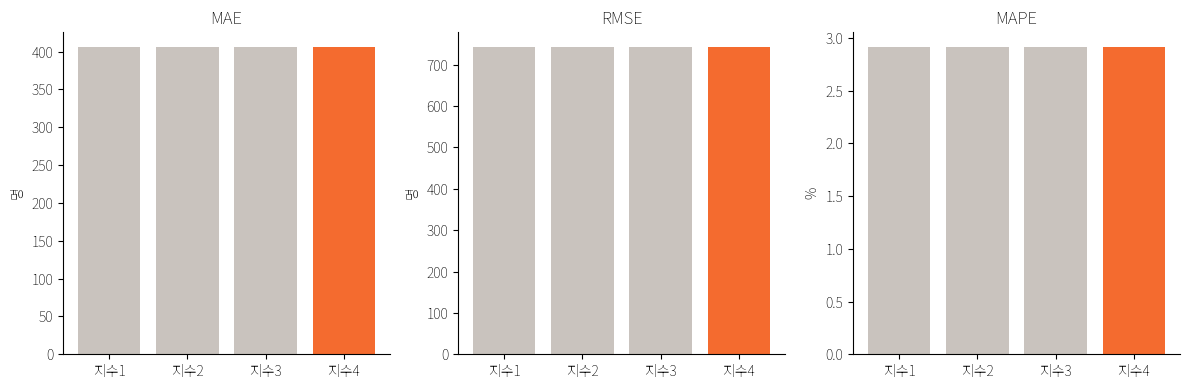

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    values = metric_table[metric] * 100 if metric == "MAPE" else metric_table[metric]
    colors = ["#C9C3BE", "#C9C3BE", "#C9C3BE", "#F46B2F"]
    ax.bar(metric_table["지수"], values, color=colors)
    ax.set_title(metric)
    ax.set_ylabel("%" if metric == "MAPE" else "명")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 최종 추정인구 정수화
- 지수 4를 최종 배분지수로 적용
- 각 500m 격자에서 소수점을 내림한 뒤, 소수점이 큰 100m 격자부터 1명씩 재분배

In [12]:
grid_estimated = grid_variables.merge(
    pop_residual[["GRID_CD", "추정인구수4"]],
    on="GRID_CD",
    how="left",
    validate="one_to_one",
).rename(columns={
    "총인구수": "원본_인구수",
    "추정인구수4": "추정_인구수",
})

grid_estimated["추정_인구수_내림"] = np.floor(
    grid_estimated["추정_인구수"]
).astype(int)
grid_estimated["소수점"] = (
    grid_estimated["추정_인구수"] - grid_estimated["추정_인구수_내림"]
)
grid_estimated["추정_인구수_정수"] = grid_estimated["추정_인구수_내림"]

integer_total = (
    grid_estimated.groupby("GRID_CD_500")["추정_인구수_내림"]
    .sum()
    .rename("추정_인구수_합")
    .reset_index()
)
integer_total = integer_total.merge(
    pop500_clean[["GRID_CD_500", "총인구수_500"]],
    on="GRID_CD_500",
    how="left",
    validate="one_to_one",
)
integer_total["분배_인구수"] = (
    integer_total["총인구수_500"] - integer_total["추정_인구수_합"]
).round().astype(int)

for grid_code, amount in integer_total[
    ["GRID_CD_500", "분배_인구수"]
].itertuples(index=False):
    if amount <= 0:
        continue

    target_index = (
        grid_estimated.loc[grid_estimated["GRID_CD_500"] == grid_code]
        .sort_values(["소수점", "GRID_CD"], ascending=[False, True])
        .head(amount)
        .index
    )
    grid_estimated.loc[target_index, "추정_인구수_정수"] += 1

grid_population_final = grid_estimated[[
    "GRID_CD",
    "행정동코드",
    "시군구",
    "행정동",
    "중심점_x",
    "중심점_y",
    "원본_인구수",
    "주거면적",
    "주택수",
    "추정_인구수_정수",
    "GRID_CD_500",
    "geometry",
]].copy()
grid_population_final = grid_population_final.rename(
    columns={"추정_인구수_정수": "추정_인구수"}
)

## 최종 결과 품질 점검

In [13]:
final_500 = (
    grid_population_final.groupby("GRID_CD_500")["추정_인구수"]
    .sum()
    .rename("추정_인구수_합")
    .reset_index()
    .merge(
        pop500_clean[["GRID_CD_500", "총인구수_500"]],
        on="GRID_CD_500",
        how="left",
        validate="one_to_one",
    )
)
final_500["오차"] = final_500["총인구수_500"] - final_500["추정_인구수_합"]

final_check = pd.Series({
    "최종 격자 수": len(grid_population_final),
    "격자 코드 중복": int(grid_population_final["GRID_CD"].duplicated().sum()),
    "전체 결측": int(grid_population_final.isna().sum().sum()),
    "음수 추정인구": int((grid_population_final["추정_인구수"] < 0).sum()),
    "최종 추정인구 합계": int(grid_population_final["추정_인구수"].sum()),
    "500m별 총량 오차 합": int(final_500["오차"].abs().sum()),
}, name="확인값")

display(final_check.to_frame())

assert final_check["최종 격자 수"] == 60528
assert final_check["격자 코드 중복"] == 0
assert final_check["전체 결측"] == 0
assert final_check["음수 추정인구"] == 0
assert final_check["최종 추정인구 합계"] == 9336665
assert final_check["500m별 총량 오차 합"] == 0

,확인값
최종 격자 수,60528
격자 코드 중복,0
전체 결측,0
음수 추정인구,0
최종 추정인구 합계,9336665
500m별 총량 오차 합,0


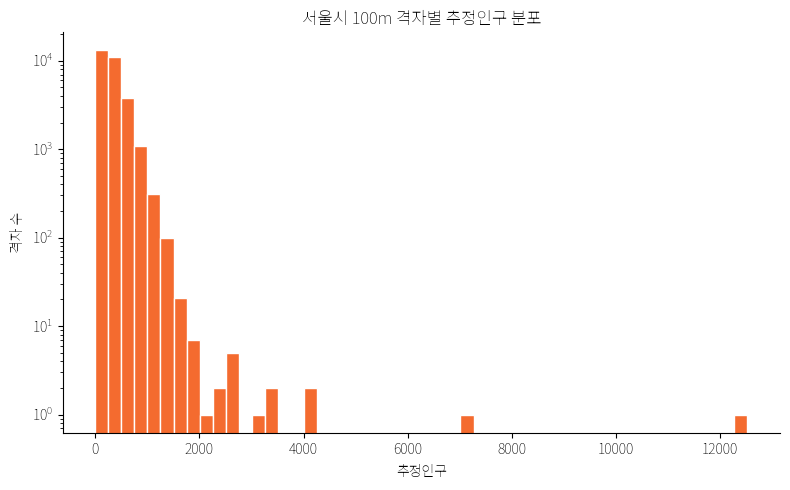

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
positive_population = grid_population_final.loc[
    grid_population_final["추정_인구수"] > 0,
    "추정_인구수",
]
ax.hist(positive_population, bins=50, color="#F46B2F", edgecolor="white")
ax.set_yscale("log")
ax.set_title("서울시 100m 격자별 추정인구 분포")
ax.set_xlabel("추정인구")
ax.set_ylabel("격자 수")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 결과 저장

In [15]:
if OUTPUT_100_FILE.exists():
    OUTPUT_100_FILE.unlink()

grid_population_final.to_file(OUTPUT_100_FILE, driver="GPKG")

saved_result = gpd.read_file(OUTPUT_100_FILE)
assert len(saved_result) == len(grid_population_final)
assert saved_result["GRID_CD"].duplicated().sum() == 0
assert saved_result["추정_인구수"].sum() == 9336665

print(f"저장 완료: {OUTPUT_100_FILE}")

저장 완료: C:\Users\ben20\Documents\DataScience\projects\Oracle-Project\data\processed\estimated_population\서울시_100m_추정인구.gpkg


## 주요 결과 요약

In [16]:
summary = pd.Series({
    "저장 파일": OUTPUT_100_FILE.name,
    "서울 100m 격자 수": f"{len(grid_population_final):,}",
    "최종 추정인구 합계": f"{grid_population_final['추정_인구수'].sum():,}명",
    "결측값": int(grid_population_final.isna().sum().sum()),
    "격자 코드 중복": int(grid_population_final["GRID_CD"].duplicated().sum()),
    "500m별 총량 오차": int(final_500["오차"].abs().sum()),
    "최종 배분지수": "인구 30% + 주택 수 50% + 주거면적 20%",
}, name="결과")

display(summary.to_frame())

,결과
저장 파일,서울시_100m_추정인구.gpkg
서울 100m 격자 수,"60,528"
최종 추정인구 합계,"9,336,665명"
결측값,0
격자 코드 중복,0
500m별 총량 오차,0
최종 배분지수,인구 30% + 주택 수 50% + 주거면적 20%
